# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [2]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




**Resposta: o teste é unilateral à direita.**

A hipótese alternativa (H1) não diz apenas que as médias são *diferentes*, ela afirma uma direção: a média da Estratégia B é **maior** que a da Estratégia A (μB > μA, ou seja, μB − μA > 0). Como a estatística do teste é calculada como a diferença (B − A) dividida pelo erro padrão, só valores **grandes e positivos** de Z trazem evidência a favor de H1. Por isso a região de rejeição fica inteira na cauda direita da distribuição normal padrão.

Se H1 dissesse "as médias são diferentes" (μB ≠ μA), o teste seria bicaudal, com a região crítica dividida entre as duas caudas. Se dissesse "B é menor que A", seria unilateral à esquerda.

Consequência prática: com α = 0,05 unilateral à direita, o valor crítico é **Z = 1,645**. Rejeitamos H0 apenas se a estatística Z calculada for maior que esse valor (o que equivale a p-value < 0,05).

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [3]:
media_A = np.mean(amostra_estrategia_A)
media_B = np.mean(amostra_estrategia_B)

# ddof=1 -> variância amostral (divide por n-1), a estimativa correta quando trabalhamos com amostras
variancia_A = np.var(amostra_estrategia_A, ddof=1)
variancia_B = np.var(amostra_estrategia_B, ddof=1)

print(f'Estratégia A -> média: {media_A:.2f} | variância: {variancia_A:.2f} | desvio padrão: {np.sqrt(variancia_A):.2f}')
print(f'Estratégia B -> média: {media_B:.2f} | variância: {variancia_B:.2f} | desvio padrão: {np.sqrt(variancia_B):.2f}')
print(f'Diferença das médias (B - A): {media_B - media_A:.2f} pontos')

Estratégia A -> média: 71.41 | variância: 129.27 | desvio padrão: 11.37
Estratégia B -> média: 74.75 | variância: 110.47 | desvio padrão: 10.51
Diferença das médias (B - A): 3.34 pontos


**Insights:**

**Médias:** a Estratégia B teve média amostral de cerca de 74,75 contra 71,41 da Estratégia A, uma diferença de aproximadamente **3,3 pontos** a favor de B. À primeira vista B parece melhor, mas uma diferença entre médias amostrais não prova, sozinha, que as estratégias diferem de fato: ela pode ser fruto da variação natural de quais alunos caíram em cada amostra. É exatamente essa dúvida que o teste Z vai responder.

**Variâncias:** as variâncias são altas em relação à diferença das médias (desvios padrão de aproximadamente 11,4 em A e 10,5 em B). Isso significa que as notas dos dois grupos se sobrepõem bastante: há muitos alunos de A com nota acima da média de B e vice-versa. Quanto maior a dispersão, mais difícil é afirmar que uma diferença de 3,3 pontos não é acaso.

**Observação crítica:** os dados foram gerados com desvio padrão populacional maior para B (12) do que para A (10), mas na amostra aconteceu o contrário (A ficou mais disperso). Isso mostra na prática a variabilidade amostral: com 50 alunos por grupo, as estatísticas da amostra não reproduzem exatamente os parâmetros da população. O mesmo vale para as médias: a diferença populacional real é de 5 pontos, mas a amostra capturou só 3,3.

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [4]:
from statsmodels.stats.weightstats import ztest

alpha = 0.05

# alternative='larger' -> H1: média(B) > média(A), teste unilateral à direita
# A ordem importa: primeiro B, depois A, pois a estatística é calculada como (B - A)
estatistica_z, p_value = ztest(amostra_estrategia_B, amostra_estrategia_A, alternative='larger')

z_critico = stats.norm.ppf(1 - alpha)  # valor crítico unilateral à direita

print(f'Estatística Z: {estatistica_z:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Z crítico (alpha = {alpha}): {z_critico:.4f}')
print()

if p_value < alpha:
    print('Decisão: REJEITAMOS a hipótese nula (p-value < 0,05).')
else:
    print('Decisão: NÃO rejeitamos a hipótese nula (p-value >= 0,05).')

Estatística Z: 1.5267
p-value: 0.0634
Z crítico (alpha = 0.05): 1.6449

Decisão: NÃO rejeitamos a hipótese nula (p-value >= 0,05).


**Resultado:** estatística Z ≈ **1,527** e p-value ≈ **0,063**.

**Decisão: não rejeitamos a hipótese nula.** O p-value (0,063) é maior que o nível de significância (0,05), e de forma equivalente a estatística Z (1,527) não ultrapassa o valor crítico (1,645). Os dois critérios levam sempre à mesma conclusão.

**Interpretação:** o p-value de 0,063 significa que, **se** as duas estratégias tivessem de fato a mesma média (H0 verdadeira), ainda assim observaríamos uma diferença igual ou maior que 3,3 pontos a favor de B em cerca de 6,3% das amostras. Esse risco é maior que os 5% que aceitamos correr, então a evidência não é forte o suficiente para afirmar que a Estratégia B é superior.

**Senso crítico sobre a conclusão:**

"Não rejeitar H0" **não** é o mesmo que "provar que as estratégias são iguais". Significa apenas que, com esta amostra, não há evidência suficiente de superioridade de B.

O resultado ficou próximo da fronteira (0,063 contra 0,05). Neste exercício sabemos que os dados foram gerados com médias populacionais diferentes (70 e 75), ou seja, B é de fato melhor na população. Como o teste não detectou essa diferença, estamos diante de um **erro tipo II** (não rejeitar uma H0 que é falsa). A causa provável é o tamanho da amostra (50 alunos) somado à alta dispersão das notas: o teste não teve poder suficiente.

Para a escola, a recomendação seria não trocar de estratégia com base apenas neste resultado, e repetir o estudo com amostras maiores para ganhar poder estatístico antes de tomar a decisão.

# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

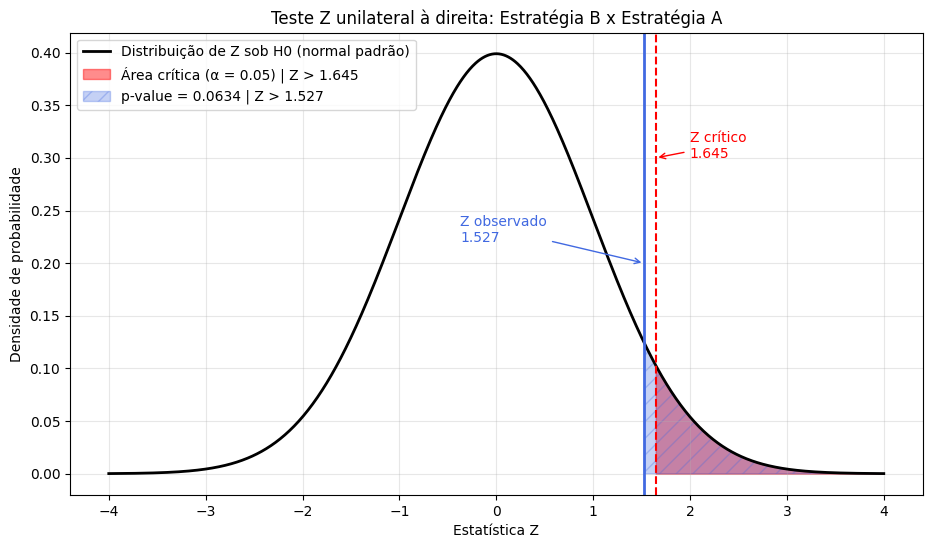

In [5]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)  # distribuição da estatística Z sob H0: normal padrão N(0, 1)

plt.figure(figsize=(11, 6))
plt.plot(x, y, color='black', linewidth=2, label='Distribuição de Z sob H0 (normal padrão)')

# Área crítica (região de rejeição): cauda direita acima do Z crítico, área = alpha = 0,05
plt.fill_between(x, y, where=(x >= z_critico), color='red', alpha=0.45,
                 label=f'Área crítica (α = {alpha}) | Z > {z_critico:.3f}')

# Área do p-value: cauda direita acima do Z observado
plt.fill_between(x, y, where=(x >= estatistica_z), color='royalblue', alpha=0.30, hatch='//',
                 label=f'p-value = {p_value:.4f} | Z > {estatistica_z:.3f}')

plt.axvline(z_critico, color='red', linestyle='--', linewidth=1.5)
plt.axvline(estatistica_z, color='royalblue', linestyle='-', linewidth=2)

plt.annotate(f'Z crítico\n{z_critico:.3f}', xy=(z_critico, 0.30), xytext=(z_critico + 0.35, 0.30),
             color='red', fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))
plt.annotate(f'Z observado\n{estatistica_z:.3f}', xy=(estatistica_z, 0.20), xytext=(estatistica_z - 1.9, 0.22),
             color='royalblue', fontsize=10, arrowprops=dict(arrowstyle='->', color='royalblue'))

plt.title('Teste Z unilateral à direita: Estratégia B x Estratégia A')
plt.xlabel('Estatística Z')
plt.ylabel('Densidade de probabilidade')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

**O que o gráfico mostra:**

A curva preta é a distribuição que a estatística Z teria **se a hipótese nula fosse verdadeira** (normal padrão, centrada em zero). Valores perto de zero são os esperados quando as médias são iguais; valores muito distantes são raros.

A **área vermelha** é a região crítica: os 5% mais extremos da cauda direita, a partir de Z = 1,645. Ela fica só do lado direito porque o teste é unilateral à direita (H1: B > A). Se a estatística observada caísse dentro dela, rejeitaríamos H0.

A **linha azul** marca o Z observado (1,527), e a **área hachurada azul** à direita dela é o p-value (≈ 0,063): a probabilidade de obter um Z igual ou maior que o nosso se H0 fosse verdadeira.

**Relação com a decisão:** o Z observado ficou **à esquerda** do Z crítico, fora da área vermelha. Visualmente, a área azul (p-value) é maior que a área vermelha (α), porque começa antes e engloba toda a região crítica mais uma faixa extra. Isso confirma graficamente a decisão da questão 3: não rejeitamos H0. O gráfico também deixa claro o quanto o resultado foi apertado, já que a linha azul ficou muito próxima da fronteira vermelha, reforçando a recomendação de repetir o estudo com uma amostra maior.